In [77]:
# 데이터셋 로드
import pandas as pd
raw_df = pd.read_csv("../data/raw/amazon.csv")
raw_df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [78]:
# 데이터셋 구조 이해 (raw)
raw_df.info()

# 모두 문자형. 형변환 필요.
# 결측치 rating_count 컬럼에 2개 존재

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   product_id           1465 non-null   str  
 1   product_name         1465 non-null   str  
 2   category             1465 non-null   str  
 3   discounted_price     1465 non-null   str  
 4   actual_price         1465 non-null   str  
 5   discount_percentage  1465 non-null   str  
 6   rating               1465 non-null   str  
 7   rating_count         1463 non-null   str  
 8   about_product        1465 non-null   str  
 9   user_id              1465 non-null   str  
 10  user_name            1465 non-null   str  
 11  review_id            1465 non-null   str  
 12  review_title         1465 non-null   str  
 13  review_content       1465 non-null   str  
 14  img_link             1465 non-null   str  
 15  product_link         1465 non-null   str  
dtypes: str(16)
memory usage: 183.3 KB


In [79]:
# 필요없는 피처 삭제
print(raw_df.columns)  # 삭제 전
df = raw_df.drop(['product_id', 'product_name', 'about_product', 'user_id', 'user_name', 'review_id', 'img_link', 'product_link'], axis=1)
print(df.columns)  # 삭제 후

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='str')
Index(['category', 'discounted_price', 'actual_price', 'discount_percentage',
       'rating', 'rating_count', 'review_title', 'review_content'],
      dtype='str')


In [80]:
df.head()

,category,discounted_price,actual_price,discount_percentage,rating,rating_count,review_title,review_content
0,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...
1,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...
2,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a..."
3,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou..."
4,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th..."


In [81]:
# 데이터셋 구조 이해
df.info()

# 모두 문자형. 형변환 필요.
# 결측치 rating_count 컬럼에 2개 존재

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   category             1465 non-null   str  
 1   discounted_price     1465 non-null   str  
 2   actual_price         1465 non-null   str  
 3   discount_percentage  1465 non-null   str  
 4   rating               1465 non-null   str  
 5   rating_count         1463 non-null   str  
 6   review_title         1465 non-null   str  
 7   review_content       1465 non-null   str  
dtypes: str(8)
memory usage: 91.7 KB


In [82]:
df.describe()

,category,discounted_price,actual_price,discount_percentage,rating,rating_count,review_title,review_content
count,1465,1465,1465,1465,1465,1463,1465,1465
unique,211,550,449,92,28,1143,1194,1212
top,Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa..."
freq,233,53,120,56,244,9,10,8


In [83]:
# rating_count 컬럼의 결측치 2개 처리 > 제거
df = df.dropna(subset=["rating_count"])
print(df.shape)

(1463, 8)


In [84]:
# 기호 제거 및 문자열의 형변환
df['discounted_price'] = (
    df['discounted_price']
        .str.replace('₹', '', regex=False)
        .str.replace(',', '', regex=False)
        .astype(float)
)

df['actual_price'] = (
    df['actual_price']
        .str.replace('₹', '', regex=False)
        .str.replace(',', '', regex=False)
        .astype(float)
)

df['discount_percentage'] = (
    df['discount_percentage']
        .str.replace('%', '', regex=False)
        .astype(float)
)

df['rating_count'] = (
    df['rating_count']
        .str.replace(',', '', regex=False)
        .astype(int)
)

In [85]:
df.head()

,category,discounted_price,actual_price,discount_percentage,rating,rating_count,review_title,review_content
0,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,24269,"Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...
1,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43.0,4.0,43994,"A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...
2,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90.0,3.9,7928,"Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a..."
3,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53.0,4.2,94363,"Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou..."
4,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61.0,4.2,16905,"As good as original,Decent,Good one for second...","Bought this instead of original apple, does th..."


In [86]:
# category 피처 제거 쉘을 제거 = category 피처 남김 (실험3)

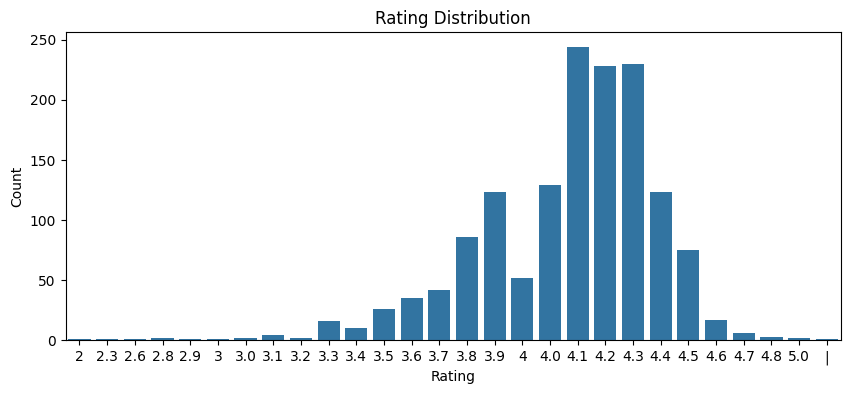

In [87]:
# rating 분포 시각화
import matplotlib.pyplot as plt
import seaborn as sns

rating_counts = df['rating'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
sns.barplot(x=rating_counts.index, y=rating_counts.values)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [88]:
# rating 별 상품 개수 확인
print(df['rating'].value_counts().sort_index().to_string())

# 위에서 형변환할 때 rating은 안해줘서 str 형태로 남아있음
# 그 결과 3과 3.0 처럼 중복 발생
# 한 샘플에 rating 이 | 로 오류 나 있음 > 그 행 제거

rating
2        1
2.3      1
2.6      1
2.8      2
2.9      1
3        1
3.0      2
3.1      4
3.2      2
3.3     16
3.4     10
3.5     26
3.6     35
3.7     42
3.8     86
3.9    123
4       52
4.0    129
4.1    244
4.2    228
4.3    230
4.4    123
4.5     75
4.6     17
4.7      6
4.8      3
5.0      2
|        1


In [89]:
# rating 피처 전처리
df['rating'] = (
    df['rating']
        .replace('|', None, regex=False)
        .astype(float)
)
df = df.dropna(subset=['rating'])
print(df.shape)

(1462, 8)


In [90]:
print(df['rating'].value_counts().sort_index().to_string())

rating
2.0      1
2.3      1
2.6      1
2.8      2
2.9      1
3.0      3
3.1      4
3.2      2
3.3     16
3.4     10
3.5     26
3.6     35
3.7     42
3.8     86
3.9    123
4.0    181
4.1    244
4.2    228
4.3    230
4.4    123
4.5     75
4.6     17
4.7      6
4.8      3
5.0      2


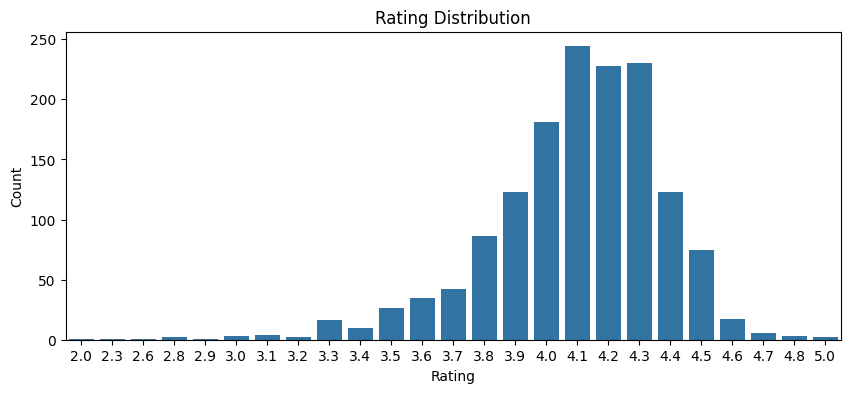

In [91]:
# rating 분포 시각화
import matplotlib.pyplot as plt
import seaborn as sns

rating_counts = df['rating'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
sns.barplot(x=rating_counts.index, y=rating_counts.values)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [92]:
# count 균형을 최대한 고려하여 Low/Mid/High 결정
# Low : ~ 4.0
# Mid : 4.1 ~ 4.2
# High : 4.3 ~
# 타깃이 될 평점 등급 피처 rating_area 생성

def assign_rating_area(rating):
  if rating <= 4.0:
    return 'Low'
  elif rating <= 4.2:
    return 'Mid'
  else:
    return 'High'
  

df['rating_area'] = df['rating'].apply(assign_rating_area)
print(df['rating_area'].value_counts())

# Low  : 534개 (36.5%)
# Mid  : 472개 (32.3%)
# High : 456개 (31.2%)

rating_area
Low     534
Mid     472
High    456
Name: count, dtype: int64


In [93]:
# rating_area 매핑 (문자열의 정수화)
rating_map = {'Low' : 0, 'Mid' : 1, 'High' : 2}
df['rating_area'] = df['rating_area'].map(rating_map)
print(df['rating_area'].value_counts())

rating_area
0    534
1    472
2    456
Name: count, dtype: int64


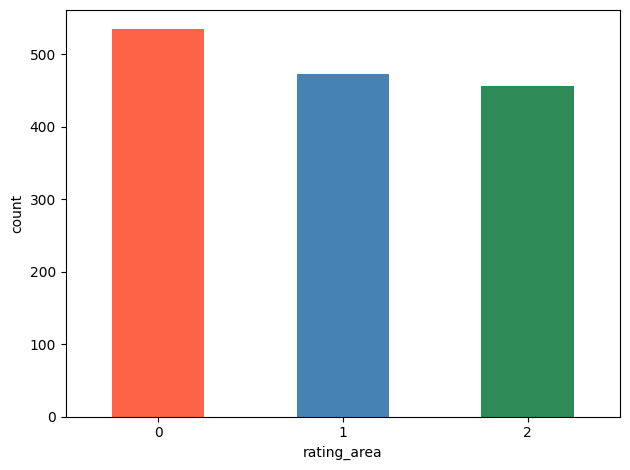

In [94]:
df['rating_area'].value_counts().plot(kind='bar', color=['tomato','steelblue','seagreen'])
plt.xlabel('rating_area')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [95]:
df.head()

,category,discounted_price,actual_price,discount_percentage,rating,rating_count,review_title,review_content,rating_area
0,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,24269,"Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,1
1,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43.0,4.0,43994,"A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,0
2,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90.0,3.9,7928,"Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",0
3,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53.0,4.2,94363,"Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",1
4,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61.0,4.2,16905,"As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",1


In [96]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['main_category'] = df['category'].apply(lambda x: x.split('|')[0])
df['category_encoded'] = le.fit_transform(df['main_category'])
df = df.drop(columns=['category', 'main_category'])

In [97]:
df.head(20)

,discounted_price,actual_price,discount_percentage,rating,rating_count,review_title,review_content,rating_area,category_encoded
0,399.00,1099.0,64.0,4.2,24269,"Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,1,1
1,199.00,349.0,43.0,4.0,43994,"A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,0,1
2,199.00,1899.0,90.0,3.9,7928,"Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",0,1
3,329.00,699.0,53.0,4.2,94363,"Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",1,1
4,154.00,399.0,61.0,4.2,16905,"As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",1,1
5,149.00,1000.0,85.0,3.9,24871,"It's pretty good,Average quality,very good and...","It's a good product.,Like,Very good item stron...",0,1
6,176.63,499.0,65.0,4.1,15188,"Long durable.,good,Does not charge Lenovo m8 t...",Build quality is good and it is comes with 2 y...,1,1
7,229.00,299.0,23.0,4.3,30411,"Worth for money - suitable for Android auto,Go...",Worth for money - suitable for Android auto......,2,1
8,499.00,999.0,50.0,4.2,179691,Works on linux for me. Get the model with ante...,I use this to connect an old PC to internet. I...,1,1
9,199.00,299.0,33.0,4.0,43994,"A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,0,1


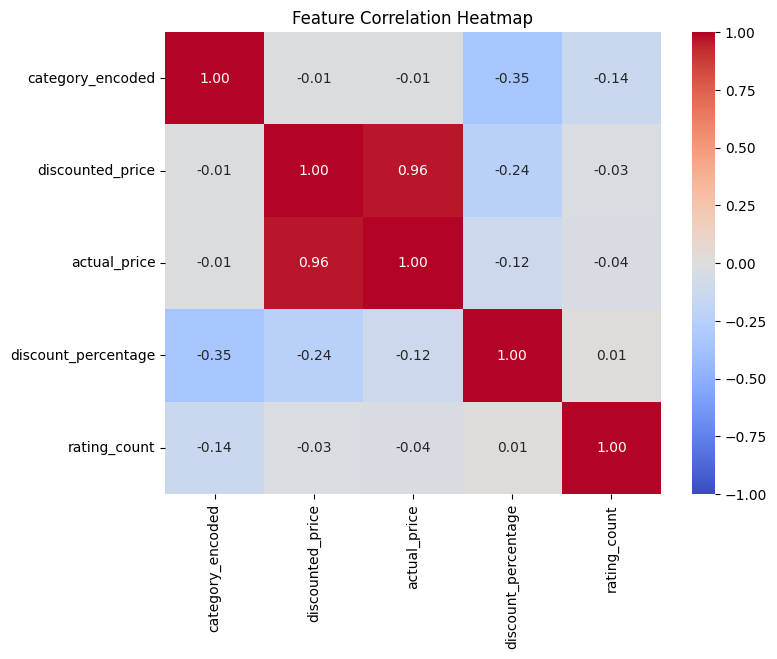

In [98]:
ml_input_features = ['category_encoded', 'discounted_price', 'actual_price', 'discount_percentage', 'rating_count']

plt.figure(figsize=(8, 6))
sns.heatmap(df[ml_input_features].corr(),
            annot = True,    # 숫자 표시
            fmt='.2f',       # 소수점 2자리
            cmap='coolwarm', # 색상
            vmin=-1, vmax=1) # 범위 고정
plt.title('Feature Correlation Heatmap')
plt.show()

In [99]:
# 상관관계가 매우 높은 discounted_price, actual_price 중 discounted_price를 제거하기로 함.
# 이에 맞춰 가설 또한 수정하려고 함.
# 자세한 건 troubleshooting.md에 기록함.

df = df.drop('discounted_price', axis=1)
df.head()

,actual_price,discount_percentage,rating,rating_count,review_title,review_content,rating_area,category_encoded
0,1099.0,64.0,4.2,24269,"Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,1,1
1,349.0,43.0,4.0,43994,"A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,0,1
2,1899.0,90.0,3.9,7928,"Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",0,1
3,699.0,53.0,4.2,94363,"Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",1,1
4,399.0,61.0,4.2,16905,"As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",1,1


In [100]:
# 전처리 데이터 저장
df.to_csv("../data/processed/processed_data_category.csv", index=False)

In [101]:
# 다음 단계 모델링에서 !
# 피처 구분 - ML X/y, LLM 입력
X = df[["actual_price", "discount_percentage", "rating_count"]]
y = df["rating_area"]
llm_input = df[["review_title", "review_content"]]